<a href="https://colab.research.google.com/github/trng1006/transfer_learning/blob/Resnet_50/transfer_learning_experiments_dogs_vs_cats_25k_resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chiến lược Transfer Learning và Fine-tuning cho bài toán phân loại ảnh

Notebook này thực hiện so sánh 3 chiến lược Transfer Learning trên bộ dữ liệu https://www.kaggle.com/datasets/biaiscience/dogs-vs-cats (Dogs vs Cats) sử dụng mô hình ResNet50:
1. **Freeze Backbone**: Chỉ huấn luyện lớp phân loại cuối cùng.
2. **Fine-tune All**: Huấn luyện lại toàn bộ mô hình.
3. **Gradual Unfreeze**: Đóng băng ban đầu và giải phóng dần các lớp.

In [ ]:
!pip install opendatasets -q
import opendatasets as od
import os
import glob
import shutil
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import copy

od.download("https://www.kaggle.com/datasets/biaiscience/dogs-vs-cats")

base_dir = './dataset'
for split in ['train', 'val']:
    for cls in ['cats', 'dogs']:
        os.makedirs(f'{base_dir}/{split}/{cls}', exist_ok=True)

print("Đang quét và phân bổ hình ảnh...")
all_images = glob.glob('./dogs-vs-cats/**/*.jpg', recursive=True)
cats = [img for img in all_images if 'cat' in os.path.basename(img).lower()]
dogs = [img for img in all_images if 'dog' in os.path.basename(img).lower()]

# 80% train - 20% val
random.seed(42)
random.shuffle(cats)
random.shuffle(dogs)

split_cat, split_dog = int(0.8 * len(cats)), int(0.8 * len(dogs))
train_cats, val_cats = cats[:split_cat], cats[split_cat:]
train_dogs, val_dogs = dogs[:split_dog], dogs[split_dog:]

def copy_files(filepaths, dest_dir):
    for f in filepaths:
        shutil.copy(f, os.path.join(dest_dir, os.path.basename(f)))

copy_files(train_cats, f'{base_dir}/train/cats')
copy_files(train_dogs, f'{base_dir}/train/dogs')
copy_files(val_cats, f'{base_dir}/val/cats')
copy_files(val_dogs, f'{base_dir}/val/dogs')

cudnn.benchmark = True
plt.ion()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Hoàn tất chuẩn bị Dataset!")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: hongquoc
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/biaiscience/dogs-vs-cats
Dataset URL: https://www.kaggle.com/datasets/biaiscience/dogs-vs-cats


  0%|          | 0.00/817M [00:00<?, ?B/s]

100%|██████████| 817M/817M [00:12<00:00, 66.0MB/s]





Đang quét và phân bổ hình ảnh...
Đang quét và phân bổ hình ảnh...
Using device: cuda:0
Hoàn tất chuẩn bị Dataset!
Using device: cuda:0
Hoàn tất chuẩn bị Dataset!
Your Kaggle username: hongquoc


## 1. Load Data

In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = './dataset'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}

# Tăng batch_size và num_workers để tối ưu tốc độ
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=32,
                                             shuffle=True, num_workers=2)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Dataset sizes: {dataset_sizes}")

Classes: ['cats', 'dogs']
Dataset sizes: {'train': 20000, 'val': 5000}


## 2. Training Function

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15, unfreeze_at=None):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Kích hoạt Unfreeze
        if unfreeze_at is not None and epoch == unfreeze_at:
            print("Unfreezing all layers...")
            for param in model.parameters():
                param.requires_grad = True
            # Giảm Learning Rate xuống 1 chút để tránh hỏng trọng số đã train
            optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
            scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, time_elapsed, best_acc.item(), history

## 3. Run Experiments

In [ ]:
def run_experiment(strategy_name):
    print(f"\n{'='*20}")
    print(f"Running Strategy: {strategy_name}")
    print(f"{'='*20}")

    # Sử dụng ResNet-50
    model_ft = models.resnet50(weights='DEFAULT')
    num_ftrs = model_ft.fc.in_features
    model_ft.fc = nn.Linear(num_ftrs, len(class_names))
    model_ft = model_ft.to(device)
    criterion = nn.CrossEntropyLoss()

    unfreeze_at = None
    if strategy_name == "Freeze Backbone":
        for param in model_ft.parameters():
            param.requires_grad = False
        for param in model_ft.fc.parameters():
            param.requires_grad = True
        optimizer = optim.SGD(model_ft.fc.parameters(), lr=0.001, momentum=0.9)

    elif strategy_name == "Fine-tune All":
        for param in model_ft.parameters():
            param.requires_grad = True
        optimizer = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

    elif strategy_name == "Gradual Unfreeze":
        for param in model_ft.parameters():
            param.requires_grad = False
        for param in model_ft.fc.parameters():
            param.requires_grad = True
        optimizer = optim.SGD(model_ft.fc.parameters(), lr=0.001, momentum=0.9)
        unfreeze_at = 5

    exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    # Đã sửa thành num_epochs=15 để Gradual Unfreeze kịp kích hoạt ở epoch 5
    return train_model(model_ft, criterion, optimizer, exp_lr_scheduler, num_epochs=15, unfreeze_at=unfreeze_at)

results = {}
strategies = ["Freeze Backbone", "Fine-tune All", "Gradual Unfreeze"]

for strategy in strategies:
    duration, best_acc, history = run_experiment(strategy)[1:]
    results[strategy] = {'duration': duration, 'best_acc': best_acc, 'history': history}


Running Strategy: Freeze Backbone
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 216MB/s]


Epoch 0/14
----------
train Loss: 0.2336 Acc: 0.9208
val Loss: 0.0731 Acc: 0.9838

Epoch 1/14
----------
train Loss: 0.1633 Acc: 0.9359
val Loss: 0.0584 Acc: 0.9856

Epoch 2/14
----------
train Loss: 0.1495 Acc: 0.9404
val Loss: 0.0522 Acc: 0.9862

Epoch 3/14
----------
train Loss: 0.1383 Acc: 0.9435
val Loss: 0.0446 Acc: 0.9880

Epoch 4/14
----------
train Loss: 0.1331 Acc: 0.9456
val Loss: 0.0440 Acc: 0.9876

Epoch 5/14
----------
train Loss: 0.1305 Acc: 0.9453
val Loss: 0.0388 Acc: 0.9890

Epoch 6/14
----------
train Loss: 0.1321 Acc: 0.9423
val Loss: 0.0388 Acc: 0.9892

Epoch 7/14
----------
train Loss: 0.1268 Acc: 0.9486
val Loss: 0.0400 Acc: 0.9886

Epoch 8/14
----------
train Loss: 0.1267 Acc: 0.9466
val Loss: 0.0382 Acc: 0.9882

Epoch 9/14
----------
train Loss: 0.1272 Acc: 0.9461
val Loss: 0.0388 Acc: 0.9884

Epoch 10/14
----------
train Loss: 0.1238 Acc: 0.9490
val Loss: 0.0425 Acc: 0.9876

Epoch 11/14
----------
train Loss: 0.1239 Acc: 0.9507
val Loss: 0.0405 Acc: 0.9886

Ep

## 4. Visualization

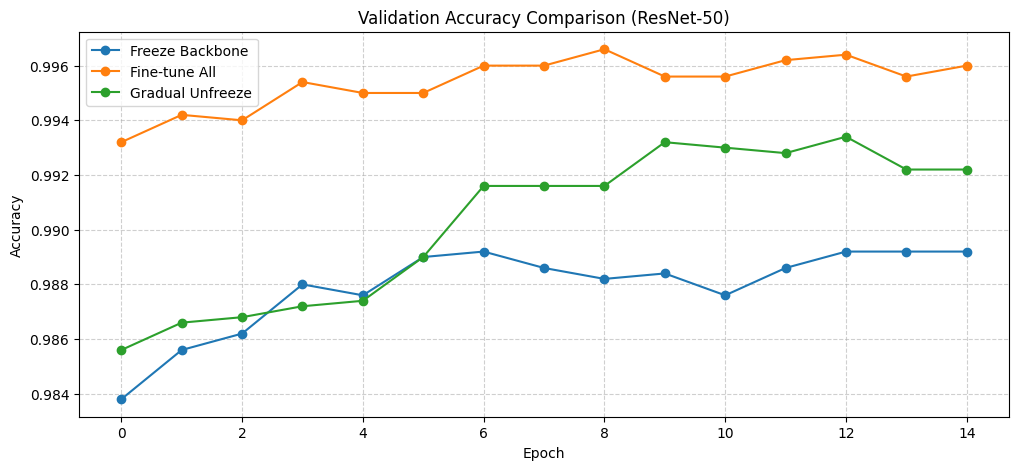


Summary Table:
Strategy             | Duration (s)    | Best Val Acc
-------------------------------------------------------
Freeze Backbone      | 1576.55         | 0.9892
Fine-tune All        | 3624.80         | 0.9966
Gradual Unfreeze     | 2943.85         | 0.9934


In [ ]:
plt.figure(figsize=(12, 5))
for strategy in strategies:
    plt.plot(results[strategy]['history']['val_acc'], label=strategy, marker='o')

plt.title('Validation Accuracy Comparison (ResNet-50)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print("\nSummary Table:")
print(f"{'Strategy':<20} | {'Duration (s)':<15} | {'Best Val Acc':<12}")
print("-" * 55)
for s, r in results.items():
    print(f"{s:<20} | {r['duration']:<15.2f} | {r['best_acc']:.4f}")

## 5. Kết luận
Dựa vào kết quả chạy thực nghiệm ở trên, ta có thể đưa ra một số nhận xét:

*   **Freeze Backbone:** Tốc độ huấn luyện nhanh nhất, độ chính xác hội tụ sớm nhưng đạt ngưỡng bão hòa thấp nhất trong ba chiến lược.
*   **Fine-tune All:** Thời gian huấn luyện lâu hơn đáng kể, nhưng mang lại kết quả độ chính xác tổng thể cao nhất.
*   **Gradual Unfreeze**: Thường cho kết quả tối ưu nhất về sự cân bằng nhờ việc giữ lại các feature đã học ở giai đoạn đầu và tinh chỉnh sâu dần ở giai đoạn sau.

Về thời gian huấn luyện: Tỷ lệ thuận với số lượng tham số cần cập nhật. Freeze Backbone có thời gian huấn luyện nhanh nhất (chỉ khoảng 26 phút - 1576.55 giây) do chỉ tính toán gradient cho lớp Linear cuối cùng. Ngược lại, Fine-tune All tiêu tốn nhiều thời gian nhất (hơn 60 phút - 3624.80 giây) vì phải lan truyền ngược qua toàn bộ kiến trúc mạng ResNet-50 khổng lồ ngay từ đầu. Gradual Unfreeze nằm ở mức giữa với khoảng 49 phút (2943.85 giây).


Về độ hội tụ (Dựa trên đồ thị):

*  Fine-tune All cho thấy quá trình học tiến triển ổn định và đạt đỉnh cao nhất, nhưng tốn kém tài nguyên.

*  Gradual Unfreeze minh họa rất rõ tác động tích cực của việc unfreeze: đồ thị cho thấy sự bứt phá về độ chính xác và giảm mạnh về Loss ở epoch thứ 6 ngay sau khi mạng được mở khóa kết hợp giảm learning rate ở epoch 5, cho thấy các trọng số đã được tinh chỉnh thành công mà không làm xáo trộn các feature ban đầu.

*  Freeze Backbone dù có dao động ở những epoch đầu nhưng lại nhanh chóng đạt được đỉnh hội tụ và đi ngang.

Kết luận chiến lược tối ưu: Đối với một bài toán phân loại ảnh có tập dữ liệu tương đối lớn (Dogs vs Cats) và có sự tương đồng rất lớn với tập ImageNet, Gradual Unfreeze là chiến lược tối ưu và toàn diện nhất. Chiến lược này mang lại độ chính xác cực kỳ ấn tượng (99.34%), vượt qua giới hạn của Freeze Backbone, đồng thời tiết kiệm hơn 11 phút huấn luyện so với Fine-tune All, chứng minh hiệu quả vượt trội của việc tái sử dụng các bộ trích xuất đặc trưng (feature extractors) kết hợp với kỹ thuật mở băng có chủ đích.